In [79]:
# Importing Libraries
import numpy as np
import pandas as pd
file = "PT_crude_processing.xlsx"
xls = pd.ExcelFile(file)
print(xls.sheet_names)

['PT_CRUDE_H', 'Monthwise 2024-25 (P)', 'Monthwise 2023-24 (P)', 'Monthwise 2022-23', 'Monthwise 2021-22 ', 'Monthwise 2020-21', 'Monthwise 2019-20', 'Monthwise 2018-19', 'Monthwise 2017-18', 'Monthwise 2016-17 ', 'Monthwise 2015-16', 'Monthwise 2014-15', 'Monthwise 2013-14', 'Monthwise 2012-13', 'Monthwise 2011-12', 'Monthwise 2010-11']


In [80]:
df_raw = pd.read_excel(file, sheet_name = "PT_CRUDE_H", header = None)

In [81]:
df_raw.shape

(64, 30)

In [82]:
df_raw.head(15)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Petroleum Planning & Analysis Cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Period : Since 1998 -99,('000 Metric Tonnes),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Crude Oil Processed by Refineries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,OIL COMPANIES,1998-99,1999-00,2000-01,2001-02,2002-03,2003-04,2004-05,2005-06,2006-07,...,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26 (P),2026-27 (Till June) (P)


In [83]:
df = df_raw.iloc[10:, :30].copy()
df.columns = ["Refinery"] + years
df = df.dropna(subset=["Refinery"]).copy()
df["Refinery"] = df["Refinery"].astype(str).str.strip()

In [84]:
def assign_company(name):
    name = name.upper().strip()

    if name.startswith("IOCL-") or name.startswith("IOCL -"):
        return "IOCL"
    elif name.startswith("HPCL-"):
        return "HPCL"
    elif name.startswith("BPCL-"):
        return "BPCL"
    elif name.startswith("CPCL-"):
        return "CPCL"
    elif name.startswith("ONGC-") or name.startswith("MRPL-"):
        return "ONGC"
    elif name.startswith("RIL"):
        return "RIL"
    
    return None

df["Company"] = df["Refinery"].apply(assign_company)

In [85]:
df = df[df["Company"].notna()].copy()

In [86]:
df = df[
    ~df["Refinery"].str.contains("TOTAL", case=False, na=False)
].copy()

In [87]:
print(df[["Company", "Refinery"]].to_string(index=False))

Company                         Refinery
   IOCL             IOCL-KOYALI, GUJARAT
   IOCL      IOCL-MATHURA, UTTAR PRADESH
   IOCL            IOCL-PANIPAT, HARYANA
   IOCL         IOCL-HALDIA, WEST BENGAL
   IOCL               IOCL-BARAUNI,BIHAR
   IOCL                IOCL-DIGBOI,ASSAM
   IOCL              IOCL-GUWAHATI,ASSAM
   IOCL            IOCL-BONGAIGAON,ASSAM
   IOCL                    IOCL -PARADIP
   HPCL          HPCL-MUMBAI,MAHARASHTRA
   HPCL       HPCL-VISAKH,ANDHRA PRADESH
   BPCL         BPCL-MUMBAI, MAHARASHTRA
   BPCL                BPCL-KOCHI,KERALA
   BPCL BPCL-BINA, SAGAR, MADHYA PRADESH
   CPCL           CPCL-MANALI, TAMILNADU
   CPCL         CPCL-NARIMANAM,TAMILNADU
   ONGC     ONGC-TATIPAKA,ANDHRA PRADESH
   ONGC         MRPL-MANGALORE,KARNATAKA
    RIL             RIL,JAMNAGAR,GUJARAT
    RIL      RIL-(SEZ), JAMNAGAR,GUJARAT


In [88]:
state_map = {
    "IOCL-KOYALI, GUJARAT": "Gujarat",
    "IOCL-MATHURA, UTTAR PRADESH": "Uttar Pradesh",
    "IOCL-PANIPAT, HARYANA": "Haryana",
    "IOCL-HALDIA, WEST BENGAL": "West Bengal",
    "IOCL-BARAUNI,BIHAR": "Bihar",
    "IOCL-DIGBOI,ASSAM": "Assam",
    "IOCL-GUWAHATI,ASSAM": "Assam",
    "IOCL-BONGAIGAON,ASSAM": "Assam",
    "IOCL -PARADIP": "Odisha",
    "HPCL-MUMBAI,MAHARASHTRA": "Maharashtra",
    "HPCL-VISAKH,ANDHRA PRADESH": "Andhra Pradesh",
    "BPCL-MUMBAI, MAHARASHTRA": "Maharashtra",
    "BPCL-KOCHI,KERALA": "Kerala",
    "BPCL-BINA, SAGAR, MADHYA PRADESH": "Madhya Pradesh",
    "CPCL-MANALI, TAMILNADU": "Tamil Nadu",
    "CPCL-NARIMANAM,TAMILNADU": "Tamil Nadu",
    "ONGC-TATIPAKA,ANDHRA PRADESH": "Andhra Pradesh",
    "MRPL-MANGALORE,KARNATAKA": "Karnataka",
    "RIL,JAMNAGAR,GUJARAT": "Gujarat",
    "RIL-(SEZ), JAMNAGAR,GUJARAT": "Gujarat"
}

df["State"] = df["Refinery"].map(state_map)

In [89]:
df[["Company", "Refinery", "State"]]

,Company,Refinery,State
11,IOCL,"IOCL-KOYALI, GUJARAT",Gujarat
12,IOCL,"IOCL-MATHURA, UTTAR PRADESH",Uttar Pradesh
13,IOCL,"IOCL-PANIPAT, HARYANA",Haryana
14,IOCL,"IOCL-HALDIA, WEST BENGAL",West Bengal
15,IOCL,"IOCL-BARAUNI,BIHAR",Bihar
16,IOCL,"IOCL-DIGBOI,ASSAM",Assam
17,IOCL,"IOCL-GUWAHATI,ASSAM",Assam
18,IOCL,"IOCL-BONGAIGAON,ASSAM",Assam
19,IOCL,IOCL -PARADIP,Odisha
23,HPCL,"HPCL-MUMBAI,MAHARASHTRA",Maharashtra


In [90]:
df["Refinery_Name"] = (
    df["Refinery"]
    .str.replace(r"^(IOCL|HPCL|BPCL|CPCL|ONGC|MRPL|RIL)\s*-\s*", "", regex=True)
    .str.replace(r"^(RIL)\s*,\s*", "", regex=True)
    .str.split(",")
    .str[0]
    .str.strip()
    .str.title()
)

In [91]:
df[["Company", "Refinery", "Refinery_Name", "State"]]

,Company,Refinery,Refinery_Name,State
11,IOCL,"IOCL-KOYALI, GUJARAT",Koyali,Gujarat
12,IOCL,"IOCL-MATHURA, UTTAR PRADESH",Mathura,Uttar Pradesh
13,IOCL,"IOCL-PANIPAT, HARYANA",Panipat,Haryana
14,IOCL,"IOCL-HALDIA, WEST BENGAL",Haldia,West Bengal
15,IOCL,"IOCL-BARAUNI,BIHAR",Barauni,Bihar
16,IOCL,"IOCL-DIGBOI,ASSAM",Digboi,Assam
17,IOCL,"IOCL-GUWAHATI,ASSAM",Guwahati,Assam
18,IOCL,"IOCL-BONGAIGAON,ASSAM",Bongaigaon,Assam
19,IOCL,IOCL -PARADIP,Paradip,Odisha
23,HPCL,"HPCL-MUMBAI,MAHARASHTRA",Mumbai,Maharashtra


In [92]:
id_cols = ["Company", "Refinery_Name", "State"]

df_long = df.melt(
    id_vars=id_cols,
    value_vars=years,
    var_name="Year",
    value_name="Crude_Processed"
)

In [93]:
df_long.head(15)

,Company,Refinery_Name,State,Year,Crude_Processed
0,IOCL,Koyali,Gujarat,1998-99,10935
1,IOCL,Mathura,Uttar Pradesh,1998-99,8909
2,IOCL,Panipat,Haryana,1998-99,2208
3,IOCL,Haldia,West Bengal,1998-99,4714
4,IOCL,Barauni,Bihar,1998-99,2204
5,IOCL,Digboi,Assam,1998-99,554
6,IOCL,Guwahati,Assam,1998-99,836
7,IOCL,Bongaigaon,Assam,1998-99,-
8,IOCL,Paradip,Odisha,1998-99,-
9,HPCL,Mumbai,Maharashtra,1998-99,5205


In [94]:
df_long.shape

(580, 5)

In [95]:
id_cols = ["Company", "Refinery_Name", "State"]

df_long = df.melt(
    id_vars=id_cols,
    value_vars=years,
    var_name="Year",
    value_name="Crude_Processed"
)

In [97]:
df_long["Crude_Processed"] = pd.to_numeric(
    df_long["Crude_Processed"],
    errors="coerce"
)

In [98]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Company          580 non-null    object 
 1   Refinery_Name    580 non-null    object 
 2   State            580 non-null    object 
 3   Year             580 non-null    object 
 4   Crude_Processed  509 non-null    float64
dtypes: float64(1), object(4)
memory usage: 22.8+ KB


In [100]:
# Missing values by refinery
missing_by_refinery = (
    df_long.groupby(["Company", "Refinery_Name"])["Crude_Processed"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)

print(missing_by_refinery)

Company  Refinery_Name
BPCL     Bina             24
IOCL     Paradip          17
         Bongaigaon       10
BPCL     Kochi             8
RIL      (Sez)             8
ONGC     Tatipaka          3
RIL      Jamnagar          1
BPCL     Mumbai            0
CPCL     Manali            0
         Narimanam         0
HPCL     Visakh            0
         Mumbai            0
IOCL     Haldia            0
         Guwahati          0
         Digboi            0
         Barauni           0
         Panipat           0
         Mathura           0
         Koyali            0
ONGC     Mangalore         0
Name: Crude_Processed, dtype: int64


In [101]:
# Missing Values by year
missing_by_year = (
    df_long.groupby("Year")["Crude_Processed"]
    .apply(lambda x: x.isna().sum())
)

print(missing_by_year)

Year
1998-99                    7
1999-00                    6
2000-01                    6
2001-02                    5
2002-03                    5
2003-04                    5
2004-05                    5
2005-06                    5
2006-07                    3
2007-08                    3
2008-09                    2
2009-10                    2
2010-11                    2
2011-12                    2
2012-13                    2
2013-14                    2
2014-15                    2
2015-16                    1
2016-17                    1
2017-18                    1
2018-19                    1
2019-20                    1
2020-21                    1
2021-22                    1
2022-23                    0
2023-24                    0
2024-25                    0
2025-26 (P)                0
2026-27 (Till June) (P)    0
Name: Crude_Processed, dtype: int64


In [108]:
# Seeing the actual missing records

missing_rows = df_long[df_long["Crude_Processed"].isna()]
missing_rows.head()

,Company,Refinery_Name,State,Year,Crude_Processed
7,IOCL,Bongaigaon,Assam,1998-99,NaN
8,IOCL,Paradip,Odisha,1998-99,NaN
12,BPCL,Kochi,Kerala,1998-99,NaN
13,BPCL,Bina,Madhya Pradesh,1998-99,NaN
16,ONGC,Tatipaka,Andhra Pradesh,1998-99,NaN


In [103]:
# Checking duplicates
duplicates = df_long.duplicated(
    subset=["Company", "Refinery_Name", "Year"]
).sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [104]:
# Checking negative values
negative_values = df_long[df_long["Crude_Processed"] < 0]

print(negative_values)

Empty DataFrame
Columns: [Company, Refinery_Name, State, Year, Crude_Processed]
Index: []


In [105]:
df_long["Refinery_Name"] = df_long["Refinery_Name"].replace({
    "(Sez)": "Jamnagar SEZ",
    "Sez": "Jamnagar SEZ"
})

In [106]:
print(df_long["Refinery_Name"].unique())

['Koyali' 'Mathura' 'Panipat' 'Haldia' 'Barauni' 'Digboi' 'Guwahati'
 'Bongaigaon' 'Paradip' 'Mumbai' 'Visakh' 'Kochi' 'Bina' 'Manali'
 'Narimanam' 'Tatipaka' 'Mangalore' 'Jamnagar' 'Jamnagar SEZ']


In [109]:
df_long["Crude_Processed_MMT"] = df_long["Crude_Processed"] / 1000

In [115]:
# India's total reported crude processing by year
yearly = (
    df_long.groupby("Year")["Crude_Processed_MMT"]
    .sum(min_count=1)
    .reset_index()
)

print(yearly)

                       Year  Crude_Processed_MMT
0                   1998-99            59.114000
1                   1999-00            75.768000
2                   2000-01            92.647000
3                   2001-02            95.961773
4                   2002-03            99.659634
5                   2003-04           106.499000
6                   2004-05           112.024888
7                   2005-06           115.558654
8                  2006-07            135.138000
9                   2007-08           139.726866
10                 2008-09            145.542520
11                  2009-10           170.441397
12                  2010-11           179.478888
13                  2011-12           185.388387
14                  2012-13           185.964214
15                 2013-14            184.915992
16                  2014-15           186.444014
17                  2015-16           194.128964
18                 2016-17            204.882705
19                 2

In [116]:
yearly["YoY_Growth_%"] = (
    yearly["Crude_Processed_MMT"].pct_change() * 100
).round(2)

yearly

,Year,Crude_Processed_MMT,YoY_Growth_%
0,1998-99,59.114000,NaN
1,1999-00,75.768000,28.17
2,2000-01,92.647000,22.28
3,2001-02,95.961773,3.58
4,2002-03,99.659634,3.85
5,2003-04,106.499000,6.86
6,2004-05,112.024888,5.19
7,2005-06,115.558654,3.15
8,2006-07,135.138000,16.94
9,2007-08,139.726866,3.40


In [117]:
# Calculating long term growth

start = yearly.loc[
    yearly["Year"] == "1998-99", "Crude_Processed_MMT"
].iloc[0]

end = yearly.loc[
    yearly["Year"] == "2025-26 (P)", "Crude_Processed_MMT"
].iloc[0]

total_growth = ((end / start) - 1) * 100

print(f"Total growth: {total_growth:.2f}%")

Total growth: 303.24%


In [119]:
# Calculating Compound Annual Growth Rate(CAGR)
years_elapsed = 27

cagr = ((end / start) ** (1 / years_elapsed) - 1) * 100

print(f"CAGR: {cagr:.2f}%")

CAGR: 5.30%


In [122]:
# Which refineries contribute the most crude processing in 2025-26?
latest = df_long[
    df_long["Year"] == "2025-26 (P)"
].copy()

latest = latest.sort_values(
    "Crude_Processed_MMT",
    ascending=False
)

print(
    latest[
        ["Company", "Refinery_Name", "State", "Crude_Processed_MMT"]
    ].to_string(index=False)
)

Company Refinery_Name          State  Crude_Processed_MMT
    RIL  Jamnagar SEZ        Gujarat            33.682332
    RIL      Jamnagar        Gujarat            33.646362
   BPCL         Kochi         Kerala            17.559450
   ONGC     Mangalore      Karnataka            16.773906
   IOCL       Paradip         Odisha            16.345755
   BPCL        Mumbai    Maharashtra            16.042344
   HPCL        Visakh Andhra Pradesh            16.036500
   IOCL       Panipat        Haryana            15.932199
   IOCL        Koyali        Gujarat            13.202134
   CPCL        Manali     Tamil Nadu            11.709718
   IOCL       Mathura  Uttar Pradesh            10.049509
   HPCL        Mumbai    Maharashtra            10.006692
   IOCL        Haldia    West Bengal             8.507224
   BPCL          Bina Madhya Pradesh             7.391041
   IOCL       Barauni          Bihar             6.380177
   IOCL    Bongaigaon          Assam             3.029371
   IOCL      G

In [123]:
# Company-level market contribution
company_latest = (
    latest.groupby("Company")["Crude_Processed_MMT"]
    .sum()
    .sort_values(ascending=False)
)

print(company_latest)

Company
IOCL    75.450428
RIL     67.328695
BPCL    40.992836
HPCL    26.043192
ONGC    16.848224
CPCL    11.709718
Name: Crude_Processed_MMT, dtype: float64


In [124]:
company_share = (
    company_latest / company_latest.sum() * 100
).round(2)

print(company_share)

Company
IOCL    31.65
RIL     28.25
BPCL    17.20
HPCL    10.93
ONGC     7.07
CPCL     4.91
Name: Crude_Processed_MMT, dtype: float64


In [127]:
# How much of the selected throughput comes from the five largest refineries?

top5 = latest.head(5)

top5_total = top5["Crude_Processed_MMT"].sum()
total = latest["Crude_Processed_MMT"].sum()

top5_share = top5_total / total * 100

print(f"Top 5 throughput: {top5_total:.2f} MMT")
print(f"Top 5 share: {top5_share:.2f}%")

Top 5 throughput: 118.01 MMT
Top 5 share: 49.51%


In [128]:
# Comparing each company's processing in 1998–99 vs 2025–26.
comparison = (
    df_long[
        df_long["Year"].isin(["1998-99", "2025-26 (P)"])
    ]
    .groupby(["Company", "Year"])["Crude_Processed_MMT"]
    .sum(min_count=1)
    .unstack()
)

comparison["Absolute_Change_MMT"] = (
    comparison["2025-26 (P)"] - comparison["1998-99"]
)

comparison["Growth_%"] = (
    (comparison["2025-26 (P)"] / comparison["1998-99"]) - 1
) * 100

print(comparison.round(2))

Year     1998-99  2025-26 (P)  Absolute_Change_MMT  Growth_%
Company                                                     
BPCL        8.87        40.99                32.12    362.00
CPCL        6.74        11.71                 4.96     73.61
HPCL        9.07        26.04                16.98    187.23
IOCL       30.36        75.45                45.09    148.52
ONGC        4.07        16.85                12.78    314.06
RIL          NaN        67.33                  NaN       NaN


In [129]:
# Comparing CAGR
comparison["CAGR_%"] = (
    (comparison["2025-26 (P)"] / comparison["1998-99"]) ** (1 / 27) - 1
) * 100

print(comparison.round(2))

Year     1998-99  2025-26 (P)  Absolute_Change_MMT  Growth_%  CAGR_%
Company                                                             
BPCL        8.87        40.99                32.12    362.00    5.83
CPCL        6.74        11.71                 4.96     73.61    2.06
HPCL        9.07        26.04                16.98    187.23    3.99
IOCL       30.36        75.45                45.09    148.52    3.43
ONGC        4.07        16.85                12.78    314.06    5.40
RIL          NaN        67.33                  NaN       NaN     NaN


In [130]:
# Covid Period Analysis
covid = (
    df_long[
        df_long["Year"].isin(["2019-20", "2020-21"])
    ]
    .groupby(["Company", "Year"])["Crude_Processed_MMT"]
    .sum(min_count=1)
    .unstack()
)

covid["Change_MMT"] = (
    covid["2020-21"] - covid["2019-20"]
)

covid["Change_%"] = (
    (covid["2020-21"] / covid["2019-20"]) - 1
) * 100

print(covid.round(2))

Year     2019-20  2020-21  Change_MMT  Change_%
Company                                        
BPCL       31.53    26.22       -5.31    -16.84
CPCL       10.16     8.24       -1.92    -18.87
HPCL       17.18    16.42       -0.76     -4.40
IOCL       69.42    62.35       -7.07    -10.18
ONGC       14.04    11.56       -2.48    -17.70
RIL        68.89    60.94       -7.95    -11.55


In [131]:
# Each company's contribution to the overall decline during covid
covid["Decline_Contribution_%"] = (
    -covid["Change_MMT"] / -covid["Change_MMT"].sum()
) * 100

print(
    covid[
        ["Change_MMT", "Change_%", "Decline_Contribution_%"]
    ].sort_values("Change_MMT")
    .round(2)
)

Year     Change_MMT  Change_%  Decline_Contribution_%
Company                                              
RIL           -7.95    -11.55                   31.20
IOCL          -7.07    -10.18                   27.73
BPCL          -5.31    -16.84                   20.83
ONGC          -2.48    -17.70                    9.75
CPCL          -1.92    -18.87                    7.52
HPCL          -0.76     -4.40                    2.96


In [132]:
# Recovery from the COVID
recovery = (
    df_long[
        df_long["Year"].isin(["2020-21", "2025-26 (P)"])
    ]
    .groupby(["Company", "Year"])["Crude_Processed_MMT"]
    .sum(min_count=1)
    .unstack()
)

recovery["Recovery_MMT"] = (
    recovery["2025-26 (P)"] - recovery["2020-21"]
)

recovery["Recovery_%"] = (
    (recovery["2025-26 (P)"] / recovery["2020-21"]) - 1
) * 100

print(recovery.round(2))

Year     2020-21  2025-26 (P)  Recovery_MMT  Recovery_%
Company                                                
BPCL       26.22        40.99         14.77       56.33
CPCL        8.24        11.71          3.47       42.06
HPCL       16.42        26.04          9.62       58.56
IOCL       62.35        75.45         13.10       21.01
ONGC       11.56        16.85          5.29       45.80
RIL        60.94        67.33          6.39       10.48


In [135]:
# Creating the refinery recovery table
import numpy as np

refinery_recovery["Recovery_%"] = refinery_recovery["Recovery_%"].replace(
    [np.inf, -np.inf], np.nan
)

def classify_recovery(row):
    if pd.isna(row["2020-21"]) or pd.isna(row["2025-26 (P)"]):
        return "Insufficient Data"
    if row["2020-21"] == 0 and row["2025-26 (P)"] == 0:
        return "No Throughput"
    if row["2020-21"] == 0 and row["2025-26 (P)"] > 0:
        return "Started/Restarted"
    if row["Recovery_MMT"] > 0:
        return "Recovered/Grew"
    if row["Recovery_MMT"] < 0:
        return "Declined"
    return "No Change"

refinery_recovery["Recovery_Status"] = (
    refinery_recovery.apply(classify_recovery, axis=1)
)

print(
    refinery_recovery[
        [
            "Company",
            "Refinery_Name",
            "2020-21",
            "2025-26 (P)",
            "Recovery_MMT",
            "Recovery_%",
            "Recovery_Status"
        ]
    ].to_string(index=False)
)

Company Refinery_Name   2020-21  2025-26 (P)  Recovery_MMT  Recovery_%   Recovery_Status
   BPCL          Bina  0.000000     7.391041      7.391041         NaN Started/Restarted
   HPCL        Visakh  9.050472    16.036500      6.986027   77.189640    Recovered/Grew
    RIL  Jamnagar SEZ 26.841275    33.682332      6.841057   25.487081    Recovered/Grew
   ONGC     Mangalore 11.474547    16.773906      5.299359   46.183596    Recovered/Grew
   BPCL         Kochi 13.281794    17.559450      4.277656   32.206915    Recovered/Grew
   IOCL       Paradip 12.507939    16.345755      3.837816   30.683041    Recovered/Grew
   CPCL        Manali  8.242890    11.709718      3.466827   42.058394    Recovered/Grew
   BPCL        Mumbai 12.940595    16.042344      3.101749   23.969140    Recovered/Grew
   IOCL       Panipat 13.181323    15.932199      2.750876   20.869498    Recovered/Grew
   HPCL        Mumbai  7.374208    10.006692      2.632484   35.698530    Recovered/Grew
   IOCL        Haldia

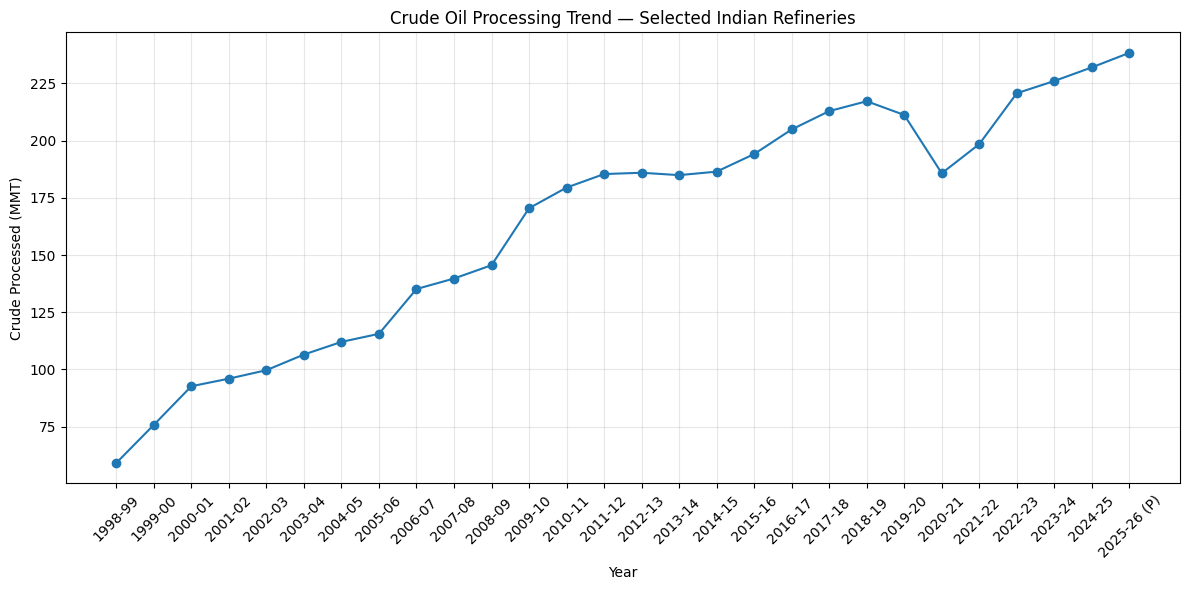

In [137]:
# Year wise crude oil processed
import matplotlib.pyplot as plt

plot_data = yearly[
    yearly["Year"] != "2026-27 (Till June) (P)"
].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_data["Year"],
    plot_data["Crude_Processed_MMT"],
    marker="o"
)

plt.title("Crude Oil Processing Trend — Selected Indian Refineries")
plt.xlabel("Year")
plt.ylabel("Crude Processed (MMT)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [138]:
# Company Throughput & Share
company_latest = (
    df_long[df_long["Year"] == "2025-26 (P)"]
    .groupby("Company")["Crude_Processed_MMT"]
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)

company_latest["Share_%"] = (
    company_latest["Crude_Processed_MMT"]
    / company_latest["Crude_Processed_MMT"].sum()
    * 100
)

company_latest

,Company,Crude_Processed_MMT,Share_%
0,CPCL,11.709718,4.912349
1,ONGC,16.848224,7.068006
2,HPCL,26.043192,10.925391
3,BPCL,40.992836,17.196922
4,RIL,67.328695,28.245090
5,IOCL,75.450428,31.652242


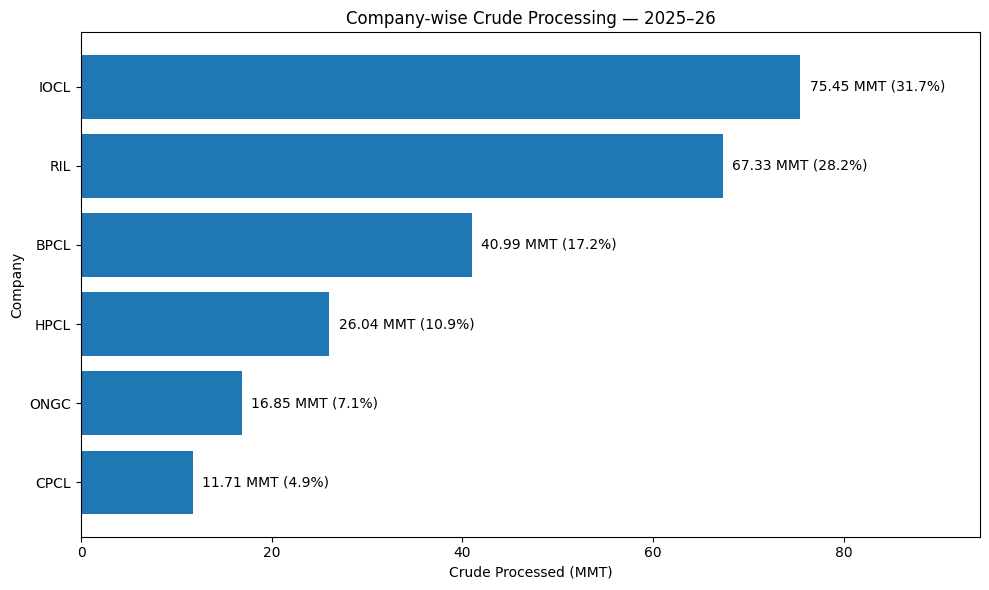

In [139]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    company_latest["Company"],
    company_latest["Crude_Processed_MMT"]
)

plt.xlabel("Crude Processed (MMT)")
plt.ylabel("Company")
plt.title("Company-wise Crude Processing — 2025–26")

for bar, share in zip(bars, company_latest["Share_%"]):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f} MMT ({share:.1f}%)",
        va="center"
    )

plt.xlim(0, company_latest["Crude_Processed_MMT"].max() * 1.25)
plt.tight_layout()
plt.show()

In [140]:
# Top 10 Refineries by Crude Processed
refinery_latest = (
    df_long[df_long["Year"] == "2025-26 (P)"]
    .groupby(
        ["Company", "Refinery_Name", "State"],
        as_index=False
    )["Crude_Processed_MMT"]
    .sum()
    .sort_values("Crude_Processed_MMT", ascending=False)
)

top10_refineries = refinery_latest.head(10)

print(top10_refineries.to_string(index=False))

Company Refinery_Name          State  Crude_Processed_MMT
    RIL  Jamnagar SEZ        Gujarat            33.682332
    RIL      Jamnagar        Gujarat            33.646362
   BPCL         Kochi         Kerala            17.559450
   ONGC     Mangalore      Karnataka            16.773906
   IOCL       Paradip         Odisha            16.345755
   BPCL        Mumbai    Maharashtra            16.042344
   HPCL        Visakh Andhra Pradesh            16.036500
   IOCL       Panipat        Haryana            15.932199
   IOCL        Koyali        Gujarat            13.202134
   CPCL        Manali     Tamil Nadu            11.709718


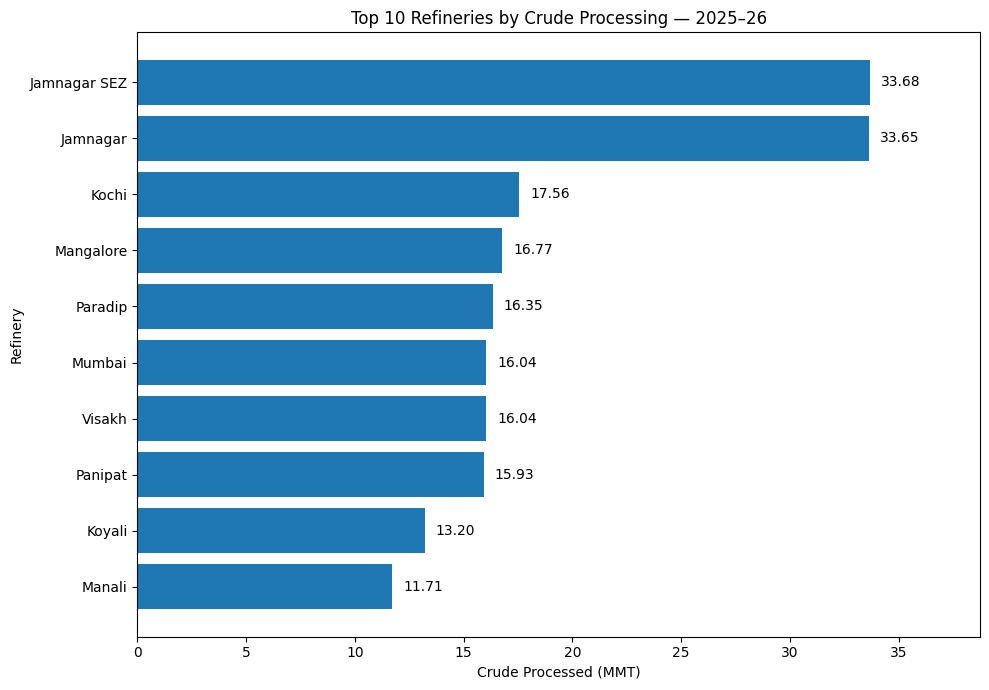

In [141]:
import matplotlib.pyplot as plt

plot_data = top10_refineries.sort_values(
    "Crude_Processed_MMT",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_data["Refinery_Name"],
    plot_data["Crude_Processed_MMT"]
)

plt.xlabel("Crude Processed (MMT)")
plt.ylabel("Refinery")
plt.title("Top 10 Refineries by Crude Processing — 2025–26")

for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}",
        va="center"
    )

plt.xlim(
    0,
    plot_data["Crude_Processed_MMT"].max() * 1.15
)

plt.tight_layout()
plt.show()